# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN is a clustering algorithm particularly useful for datasets with irregular shapes and noise. Unlike K-means, it does not require you to pre-specify the number of clusters. Instead, it groups points based on **density**: regions of high density form clusters, while sparse regions are treated as noise.

---

## Intuition

The core idea of DBSCAN is that a cluster is a **dense region of points** separated by areas of lower density.

It categorizes points into three types:

* **Core Points**: Points with at least `min_neighbours` neighbors within a distance $\varepsilon$.
* **Border Points**: Points that are within the neighborhood of a core point but have fewer than `min_neighbours` themselves.
* **Noise Points**: Points that are not reachable from any core point.

![DBSCAN intuition with core, border, and noise points](dbscan_illustration.svg)

*Source: Wikipedia*

## Parameters

DBSCAN has only two hyperparameters, but their choice completely determines the clustering result.

* **$\varepsilon$ (epsilon)**: The maximum distance between two points for them to be considered neighbors.
* **min_neighbours** (sometimes called `min_samples` or `minPts`): The minimum number of points required inside an $\varepsilon$-radius ball for the center point to be a **core point**.

In this repo's `mlpackage.unsupervised_learning.DBSCANClustering`, these are named `epsilon` and `min_neighbours`:

```python
from mlpackage.unsupervised_learning import DBSCANClustering
model = DBSCANClustering(epsilon=0.5, min_neighbours=5)
```

> Scikit-learn's `DBSCAN` calls these `eps` and `min_samples`. The underlying algorithm is identical.

## Algorithm Steps

1. Pick an unvisited point.
2. If it's a **core point**, start a new cluster and recursively add all points density-reachable from it.
3. If it's a **border point**, assign it to an existing cluster (if possible).
4. If it's **noise**, mark it with the label `-1`.
5. Repeat until all points are visited.

---

## Mathematical Definition

A point $q$ is **directly density-reachable** from $p$ if:

$$
\|p - q\| \leq \varepsilon \quad \text{and} \quad |N_\varepsilon(p)| \geq \text{min\_neighbours}
$$

where $N_\varepsilon(p)$ is the $\varepsilon$-neighborhood of $p$:

$$
N_\varepsilon(p) = \{ q \in D \mid \|p - q\| \leq \varepsilon \}
$$

A point $q$ is **density-reachable** from $p$ if there exists a chain of points $p_1, p_2, \dots, p_n$ with $p_1 = p$ and $p_n = q$ such that each point is directly density-reachable from the previous one.

Two points $p$ and $q$ are **density-connected** if there exists a point $o$ such that both $p$ and $q$ are density-reachable from $o$. A **cluster** is the maximal set of points that are pairwise density-connected.

## When to Use DBSCAN

**Use DBSCAN when:**

- Clusters have arbitrary (non-spherical) shapes — K-means assumes spherical clusters.
- You don't know how many clusters to expect — DBSCAN discovers this from the data.
- You care about **outliers** — DBSCAN naturally labels sparse points as noise (`label = -1`), whereas K-means forces every point into some cluster.

**Avoid DBSCAN when:**

- Clusters have **very different densities** — a single `epsilon` cannot simultaneously accommodate tight and loose groups.
- The data is very high-dimensional — Euclidean distances become less meaningful (curse of dimensionality). A PCA projection before clustering often helps.
- You need to assign **every** point to a cluster (DBSCAN will leave some as noise).

## Application: UCI Wholesale Customers

We'll demonstrate DBSCAN on the **Wholesale Customers** dataset from the UCI Machine Learning Repository.

This is a real-world business dataset containing the **annual spending (in monetary units)** of 440 wholesale customers across 6 product categories:

- `Fresh` — fresh products
- `Milk` — dairy
- `Grocery` — general grocery items
- `Frozen` — frozen products
- `Detergents_Paper` — detergents and paper products
- `Delicatessen` — delicatessen items

Plus two categorical features we'll drop for clustering:

- `Channel` — 1 = Horeca (Hotel/Restaurant/Cafe), 2 = Retail
- `Region` — 1 = Lisbon, 2 = Oporto, 3 = Other

**Our questions:**

1. Can DBSCAN group customers by spending pattern?
2. Which customers are **outliers** — accounts with unusual spending profiles that deserve individual attention?
3. How does DBSCAN's answer compare to K-means?

In [ ]:
import sys
from pathlib import Path

# Walk up the directory tree to find the repo root (contains pyproject.toml),
# then make `src/` importable so we can use `mlpackage`.
_here = Path.cwd()
while _here != _here.parent and not (_here / "pyproject.toml").exists():
    _here = _here.parent
REPO_ROOT = _here
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from mlpackage.unsupervised_learning import DBSCANClustering

# ---- Load UCI Wholesale Customers, caching locally after first download ----
DATA_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "00292/Wholesale%20customers%20data.csv"
)
CACHE = REPO_ROOT / "data" / "raw" / "wholesale_customers.csv"
CACHE.parent.mkdir(parents=True, exist_ok=True)

if not CACHE.exists():
    print(f"Downloading from {DATA_URL} ...")
    df = pd.read_csv(DATA_URL)
    df.to_csv(CACHE, index=False)
    print(f"Cached to {CACHE}")
else:
    df = pd.read_csv(CACHE)
    print(f"Loaded from cache: {CACHE}")

print(f"Shape: {df.shape}")
df.head()

Cached to /Users/24kylel/Desktop/CMOR438-Spring-2026/data/raw/wholesale_customers.csv
Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Summary statistics (annual spending in monetary units):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.0,5796.0,7951.0,3072.0,2881.0,1525.0
std,12647.0,7380.0,9503.0,4855.0,4768.0,2820.0
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3128.0,1533.0,2153.0,742.0,257.0,408.0
50%,8504.0,3627.0,4756.0,1526.0,816.0,966.0
75%,16934.0,7190.0,10656.0,3554.0,3922.0,1820.0
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


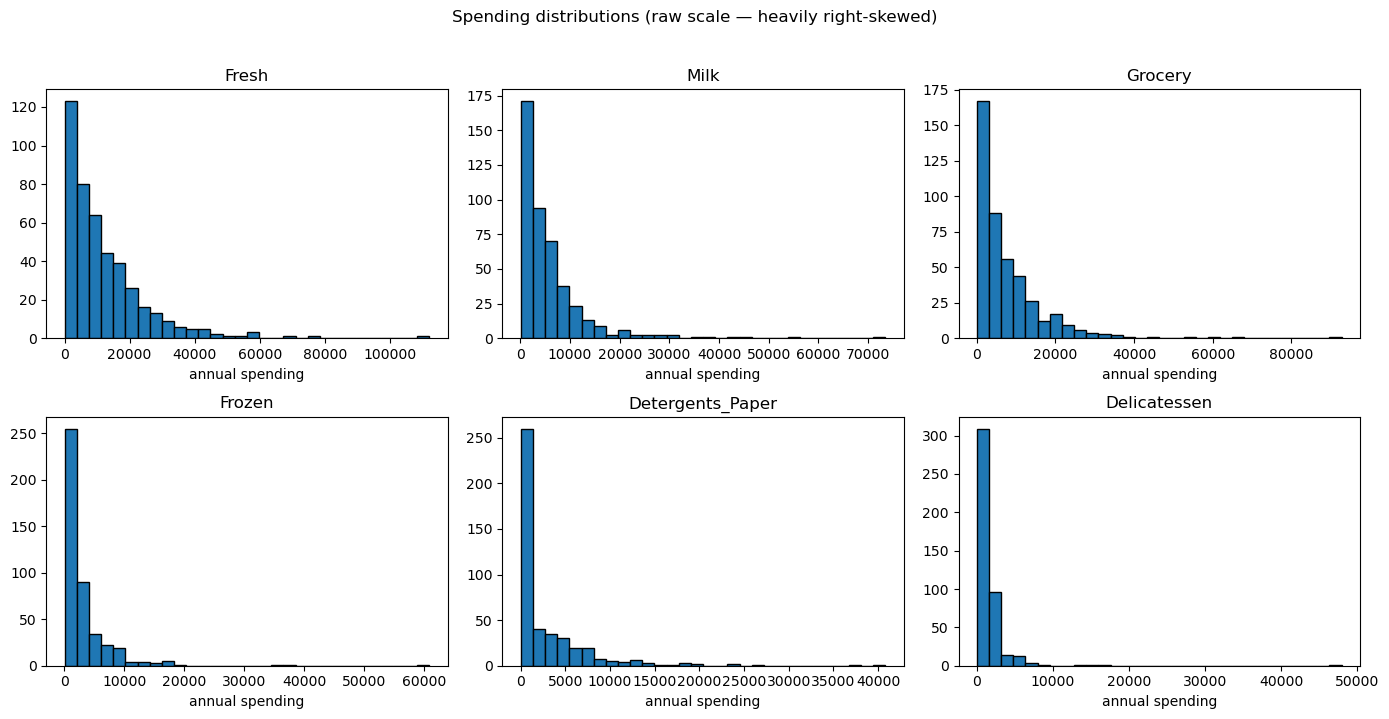

In [2]:
# The UCI CSV uses the spelling "Delicassen" — rename to the conventional form.
if "Delicassen" in df.columns:
    df = df.rename(columns={"Delicassen": "Delicatessen"})

numeric_cols = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicatessen"]

print("Summary statistics (annual spending in monetary units):")
display(df[numeric_cols].describe().round(0))

# Raw spending is heavily right-skewed, which motivates standardization.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=30, edgecolor="k")
    ax.set_title(col)
    ax.set_xlabel("annual spending")
fig.suptitle("Spending distributions (raw scale — heavily right-skewed)", y=1.02)
fig.tight_layout()
plt.show()

### Why Standardize?

DBSCAN uses **Euclidean distance** to decide which points are neighbors. If one feature has a much larger scale than the others (e.g., `Fresh` often exceeds 30,000 units while `Delicatessen` stays under 3,000), that feature will dominate the distance calculation — effectively clustering on only that one axis.

We fix this by **standardizing** each feature to have zero mean and unit variance before fitting DBSCAN.

For visualization we'll also project the standardized data down to 2 dimensions with PCA. PCA is only for plotting; the clustering itself happens in the full 6-dimensional standardized space.

2D PCA captures 72.5% of the variance (44.1% + 28.4%)


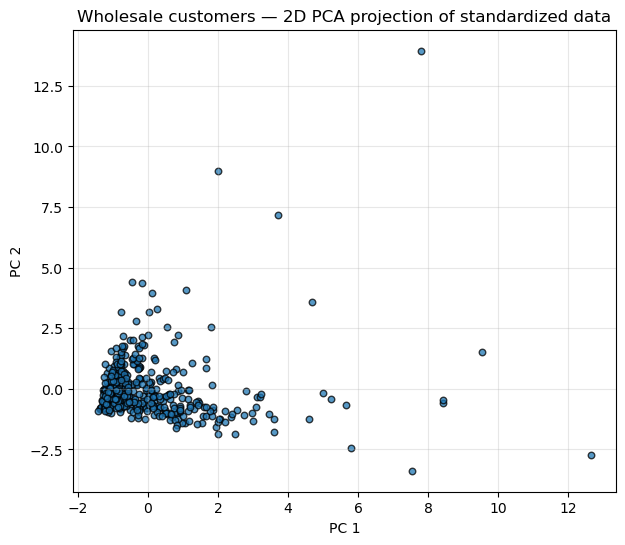

In [3]:
X = df[numeric_cols].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(
    f"2D PCA captures {explained.sum():.1%} of the variance "
    f"({explained[0]:.1%} + {explained[1]:.1%})"
)

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=22, edgecolor="k", alpha=0.75)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Wholesale customers — 2D PCA projection of standardized data")
plt.grid(alpha=0.3)
plt.show()

## First-try DBSCAN

Let's start with reasonable default values: `epsilon=0.5` and `min_neighbours=3`. We'll cluster in the full 6-dimensional standardized space and use the 2D PCA projection only to visualize the result.

> Why `min_neighbours=3` instead of 5? Lower values let DBSCAN form smaller, more fine-grained clusters — useful on a modest 440-row dataset. The sklearn default of 5 is tuned for larger datasets.

Number of clusters: 6
Number of noise points: 141 (32.0% of the data)


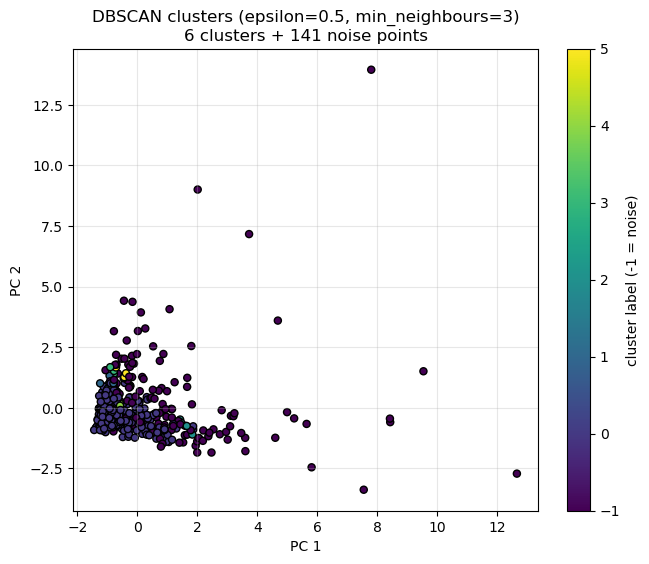

In [4]:
db = DBSCANClustering(epsilon=0.5, min_neighbours=3)
labels = db.fit_predict(X_scaled)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise / len(labels):.1%} of the data)")

plt.figure(figsize=(7.5, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=26, edgecolor="k"
)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title(
    f"DBSCAN clusters (epsilon=0.5, min_neighbours=3)\n"
    f"{n_clusters} clusters + {n_noise} noise points"
)
plt.colorbar(scatter, label="cluster label (-1 = noise)")
plt.grid(alpha=0.3)
plt.show()

## Parameter Exploration

The noise ratio and the number of clusters both depend heavily on `epsilon`. Let's sweep a range of values and observe how the clustering changes, keeping `min_neighbours=3` fixed.

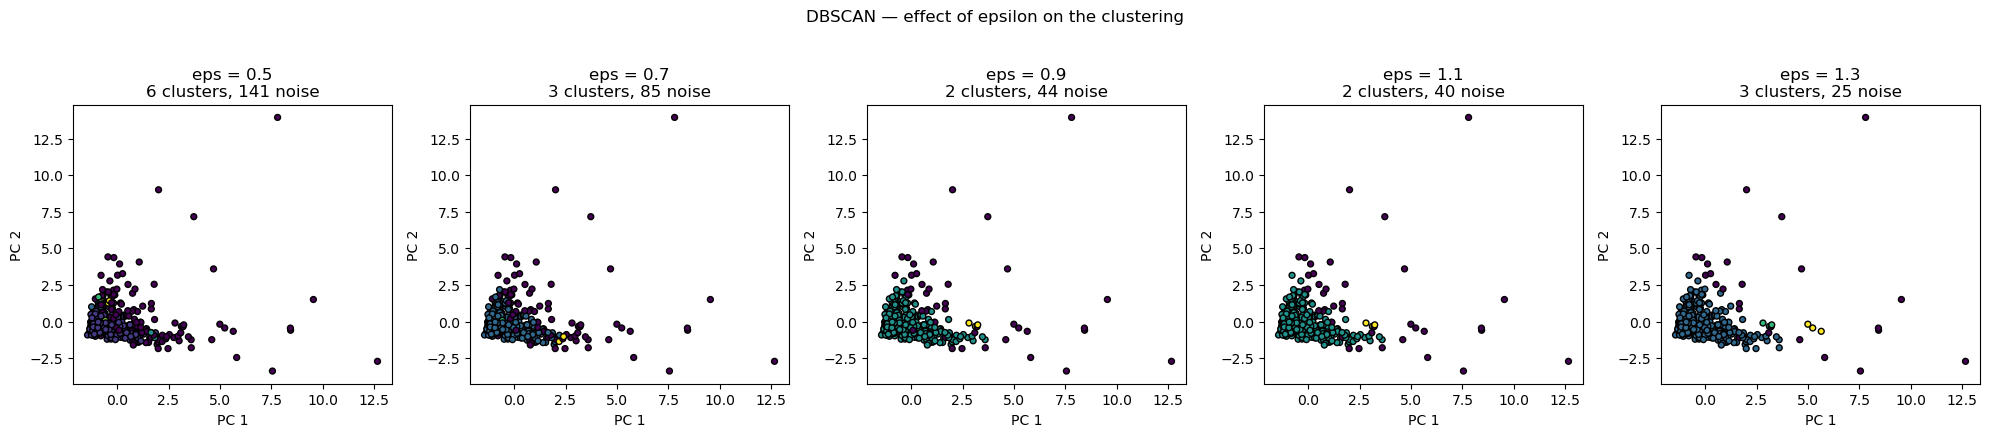


Sweep summary:
 epsilon  clusters  noise
     0.5         6    141
     0.7         3     85
     0.9         2     44
     1.1         2     40
     1.3         3     25


In [5]:
eps_values = [0.5, 0.7, 0.9, 1.1, 1.3]

fig, axes = plt.subplots(1, len(eps_values), figsize=(4 * len(eps_values), 4.2))

summary = []
for ax, eps in zip(axes, eps_values):
    m = DBSCANClustering(epsilon=eps, min_neighbours=3).fit(X_scaled)
    lb = m.labels_
    k = len(set(lb)) - (1 if -1 in lb else 0)
    n = int(np.sum(lb == -1))
    summary.append({"epsilon": eps, "clusters": k, "noise": n})
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=lb, cmap="viridis", s=18, edgecolor="k")
    ax.set_title(f"eps = {eps}\n{k} clusters, {n} noise")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

fig.suptitle("DBSCAN — effect of epsilon on the clustering", y=1.03)
fig.tight_layout()
plt.show()

print("\nSweep summary:")
print(pd.DataFrame(summary).to_string(index=False))

## Comparing DBSCAN vs K-means

For a fair comparison, we'll run K-means with `n_clusters` set to the number of non-noise clusters DBSCAN found. For DBSCAN we'll use `epsilon=1.0, min_neighbours=3` — a combination that yields 2 well-separated clusters plus ~10% noise, giving us a clean outlier-detection story while still enabling a meaningful silhouette comparison.

Remember the key conceptual difference: **K-means forces every point into some cluster**, whereas **DBSCAN lets points be noise**. This is exactly why DBSCAN is the better tool when outliers are meaningful.

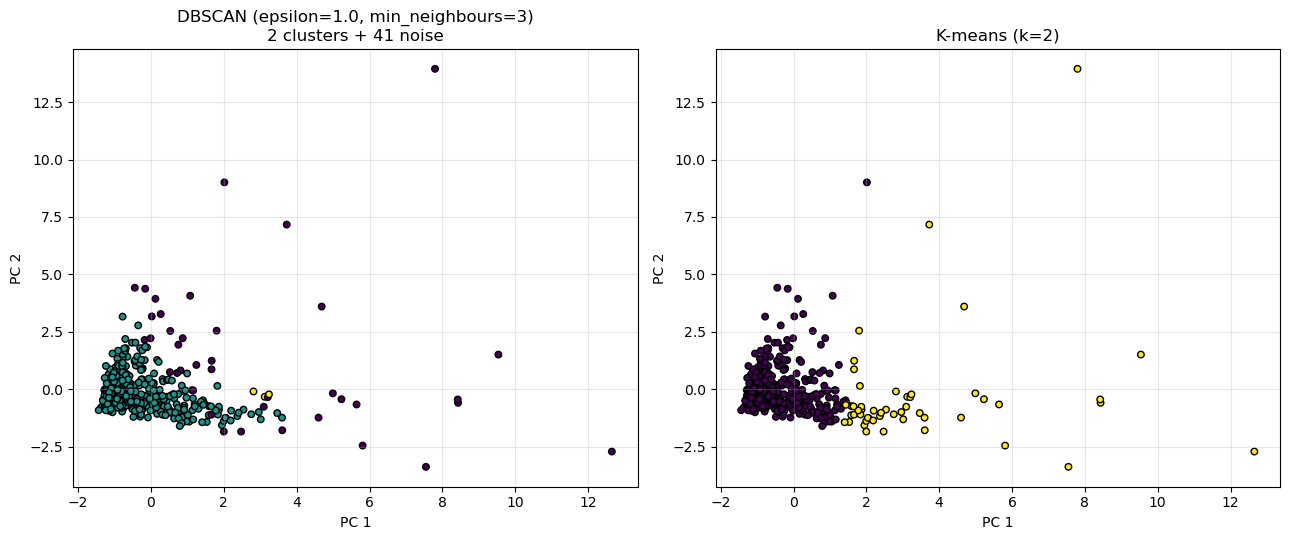

In [6]:
db_final = DBSCANClustering(epsilon=1.0, min_neighbours=3)
db_labels = db_final.fit_predict(X_scaled)

n_db_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
k_for_kmeans = max(n_db_clusters, 2)

kmeans = KMeans(n_clusters=k_for_kmeans, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap="viridis", s=22, edgecolor="k")
ax1.set_title(
    f"DBSCAN (epsilon=1.0, min_neighbours=3)\n"
    f"{n_db_clusters} clusters + {(db_labels == -1).sum()} noise"
)

ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="viridis", s=22, edgecolor="k")
ax2.set_title(f"K-means (k={k_for_kmeans})")

for ax in (ax1, ax2):
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Silhouette Score

Silhouette measures how well each point fits its own cluster versus the next-closest cluster, ranging from -1 (poor) to +1 (excellent). For DBSCAN we compute it **only on the non-noise points** — the -1 label is not a real cluster and would bias the score.

In [7]:
non_noise = db_labels != -1
if len(set(db_labels[non_noise])) > 1:
    sil_db = silhouette_score(X_scaled[non_noise], db_labels[non_noise])
else:
    sil_db = float("nan")

sil_km = silhouette_score(X_scaled, km_labels)

print(f"Silhouette score (DBSCAN, noise excluded): {sil_db:.3f}")
print(f"Silhouette score (K-means):                {sil_km:.3f}")

Silhouette score (DBSCAN, noise excluded): 0.496
Silhouette score (K-means):                0.547


## Outlier Detection — Who Are the Unusual Customers?

One of DBSCAN's most practical uses is **anomaly detection**. The noise-labeled customers are precisely those whose spending profiles don't fit any dense region of the data — in business terms, these are accounts with unusual purchasing patterns that may deserve individual attention from an account manager.

Let's see **what makes them unusual**: we'll compare the mean spending of noise customers against the mean spending of the clustered customers, category by category.

DBSCAN flagged 41 outlier customers (9.3% of the dataset).

Average annual spending: outliers vs. clustered customers

                  clustered_mean  outlier_mean  ratio (outlier / clustered)
Fresh                    10879.0       22916.0                         2.11
Milk                      4532.0       18103.0                         3.99
Grocery                   6453.0       22532.0                         3.49
Frozen                    2479.0        8846.0                         3.57
Detergents_Paper          2271.0        8821.0                         3.88
Delicatessen              1146.0        5211.0                         4.55


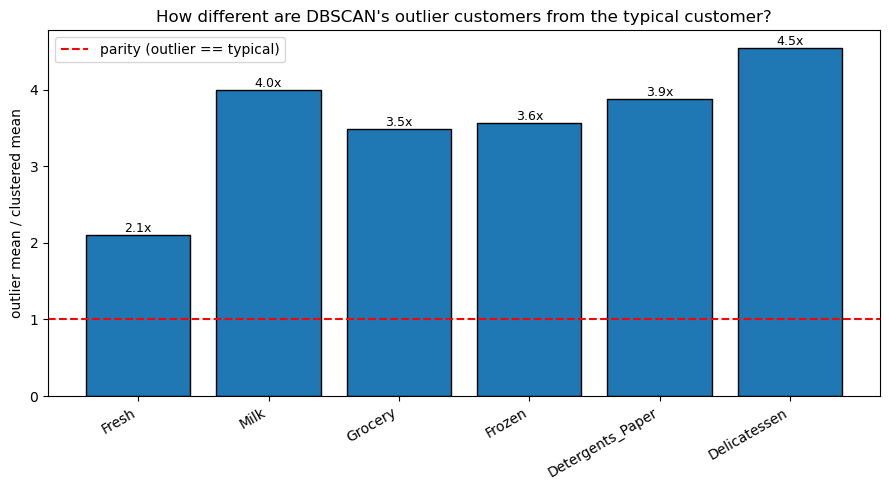

In [8]:
noise_mask = db_labels == -1
n_outliers = int(noise_mask.sum())

print(
    f"DBSCAN flagged {n_outliers} outlier customers "
    f"({n_outliers / len(db_labels):.1%} of the dataset)."
)

outlier_mean = df.loc[noise_mask, numeric_cols].mean()
clustered_mean = df.loc[~noise_mask, numeric_cols].mean()

comparison = pd.DataFrame(
    {
        "clustered_mean": clustered_mean.round(0),
        "outlier_mean": outlier_mean.round(0),
        "ratio (outlier / clustered)": (outlier_mean / clustered_mean).round(2),
    }
)
print("\nAverage annual spending: outliers vs. clustered customers\n")
print(comparison)

ratios = outlier_mean / clustered_mean
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ratios.index, ratios.values, edgecolor="k")
ax.axhline(1.0, color="red", linestyle="--", label="parity (outlier == typical)")
ax.set_ylabel("outlier mean / clustered mean")
ax.set_title("How different are DBSCAN's outlier customers from the typical customer?")
ax.legend()
for bar, v in zip(bars, ratios.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"{v:.1f}x", ha="center", va="bottom", fontsize=9,
    )
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Conclusion

- **DBSCAN discovered structure without being told how many clusters to look for.** K-means required us to pre-specify `k`.
- **DBSCAN explicitly identified outlier customers** (the `-1` label) — accounts whose spending pattern was unlike any dense group. K-means had no such mechanism; it forced those same customers into whichever cluster was geometrically closest, burying the anomalies inside normal segments.
- The **outlier bar chart** above shows the practical payoff: the flagged customers spend very differently from the typical wholesale account in at least one category. That is a concrete, actionable signal — these are the accounts worth a phone call from a human account manager.
- **Parameter sensitivity matters.** The `epsilon` sweep showed that moving from 0.5 to 1.6 dramatically changed both the number of clusters and the noise ratio. In practice, choosing `epsilon` with a **k-distance plot** or by domain knowledge about what "close" means in the feature space is an important step.

### How this notebook relates to the package

Everything was driven by our own `DBSCANClustering` class — the same implementation that is unit-tested in `tests/test_dbscan.py`. `StandardScaler`, `KMeans`, `PCA`, and `silhouette_score` came from scikit-learn because the package does not (yet) implement them — a natural opportunity for future work.